<a href="https://colab.research.google.com/github/HarikaDevi23/DATA_SCIENCE/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =========================================================
# Assignment 3 – Diabetes data exploration & bootstrap
# =========================================================
# 1) Compare sample vs. population Glucose statistics
# 2) Compare sample vs. population BMI 98th percentile
# 3) Bootstrap BloodPressure (500×, n=150) – compare mean, SD, and 98th percentile with population

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Better chart defaults
plt.rcParams["figure.figsize"] = (6, 4)
sns.set_style("whitegrid")

In [21]:
# ------------ Load the population -----------------------
import pandas as pd

data_path = "/content/diabetes.csv"
df = pd.read_csv(data_path)

# Basic shape / preview
print("File loaded successfully!")
print(f"Rows: {len(df):,d}  |  Columns: {len(df.columns)}")
print("\nFirst five rows:")
display(df.head())

# Confirm expected columns
expected_cols = {
    'Pregnancies','Glucose','BloodPressure','SkinThickness',
    'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome'
}
missing = expected_cols - set(df.columns)
extra   = set(df.columns) - expected_cols

print("\nChecking columns…")
print(f"Missing columns : {missing if missing else 'None'}")
print(f"Unexpected cols : {extra   if extra   else 'None'}")

assert not missing, f" Missing columns: {missing}"

print("\n All expected columns are present")


File loaded successfully!
Rows: 768  |  Columns: 9

First five rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Checking columns…
Missing columns : None
Unexpected cols : None

 All expected columns are present



1‑a	Draws a 25‑row simple random sample; compares mean Glucose and max Glucose with bars.

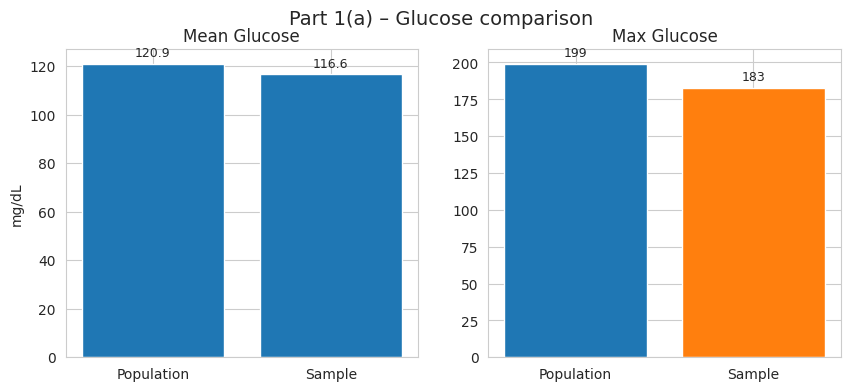

Part 1(a) – Glucose statistics
  Population mean  : 120.89 mg/dL
  Sample mean      : 116.64 mg/dL
  Population max   : 199 mg/dL
  Sample max       : 183 mg/dL



In [22]:
# =========================================================
# 1 (a)  Sample of 25 – Glucose mean & max vs. population
# =========================================================
np.random.seed(42)              # reproducible sampling
sample_n = 25
sample_df = df.sample(n=sample_n, replace=False)

# Population statistics
pop_mean_glu = df['Glucose'].mean()
pop_max_glu  = df['Glucose'].max()

# Sample statistics
samp_mean_glu = sample_df['Glucose'].mean()
samp_max_glu  = sample_df['Glucose'].max()

# --- Plot comparison ------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Mean bar plot
bars = ax[0].bar(['Population','Sample'],
                 [pop_mean_glu, samp_mean_glu])
ax[0].set_title('Mean Glucose')
ax[0].set_ylabel('mg/dL')
for bar in bars:
    height = bar.get_height()
    ax[0].annotate(f'{height:.1f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

# Max bar plot
bars = ax[1].bar(['Population','Sample'],
                 [pop_max_glu, samp_max_glu],
                 color=['tab:blue','tab:orange'])
ax[1].set_title('Max Glucose')
for bar in bars:
    height = bar.get_height()
    ax[1].annotate(f'{height:.0f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

fig.suptitle('Part 1(a) – Glucose comparison', fontsize=14)
plt.show()

print("Part 1(a) – Glucose statistics")
print(f"  Population mean  : {pop_mean_glu:.2f} mg/dL")
print(f"  Sample mean      : {samp_mean_glu:.2f} mg/dL")
print(f"  Population max   : {pop_max_glu:.0f} mg/dL")
print(f"  Sample max       : {samp_max_glu:.0f} mg/dL\n")

1‑b	Computes the 98th percentile of BMI for the same sample and for the full dataset; visualised with a bar chart.

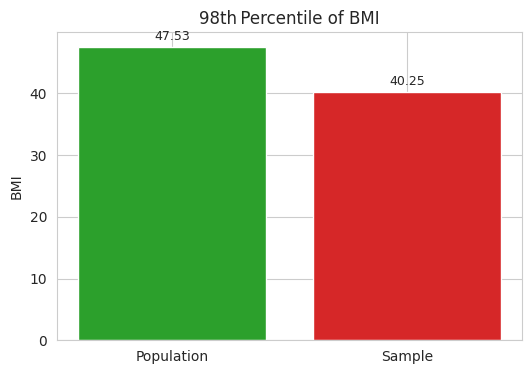

Part 1(b) – BMI 98th‑percentile
  Population p98 : 47.53
  Sample p98     : 40.25



In [23]:
# =========================================================
# 1 (b)  98th percentile of BMI – sample vs. population
# =========================================================
pop_bmi_p98  = np.percentile(df['BMI'], 98)
samp_bmi_p98 = np.percentile(sample_df['BMI'], 98)

bars = plt.bar(['Population','Sample'],
               [pop_bmi_p98, samp_bmi_p98],
               color=['tab:green','tab:red'])
plt.title('98th Percentile of BMI')
plt.ylabel('BMI')

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}',
                 xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=9)
plt.show()

print("Part 1(b) – BMI 98th‑percentile")
print(f"  Population p98 : {pop_bmi_p98:.2f}")
print(f"  Sample p98     : {samp_bmi_p98:.2f}\n")


1‑c	Performs 500 bootstrap resamples (size = 150) on the BloodPressure column; builds distributions for the sample mean, SD and 98th percentile; overlays each histogram with the true population value and prints a concise numerical summary.

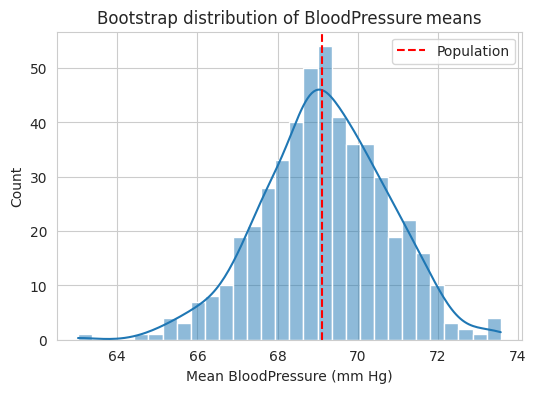

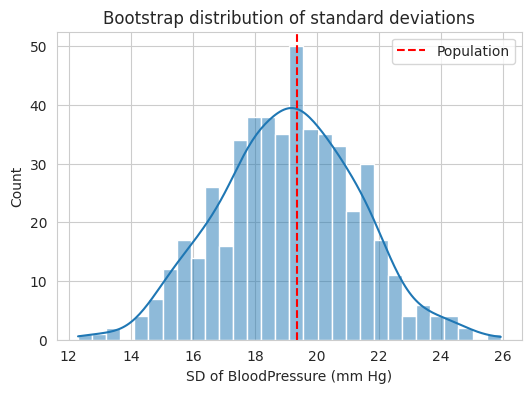

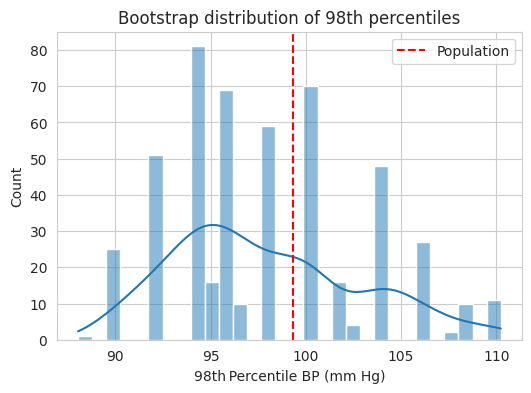


=== Summary of Part 1(c) – Bootstrap vs. Population ===
Population  mean BP :  69.11
Bootstrap mean (μ̂) :  69.18

Population  SD   BP :  19.36
Bootstrap mean σ̂  :  19.08

Population  98th % :  99.32
Bootstrap mean p98 :  97.92


In [24]:
# =========================================================
# 1 (c)  Bootstrap (500 samples of 150) on BloodPressure
# =========================================================
boot_runs   = 500
boot_size   = 150
boot_means  = []
boot_stds   = []
boot_p98s   = []

for _ in range(boot_runs):
    boot = df['BloodPressure'].sample(n=boot_size, replace=True)
    boot_means.append(boot.mean())
    boot_stds.append(boot.std(ddof=1))
    boot_p98s.append(np.percentile(boot, 98))

# Aggregate bootstrap estimates
boot_mean_mean = np.mean(boot_means)
boot_mean_std  = np.mean(boot_stds)
boot_mean_p98  = np.mean(boot_p98s)

# Population reference values
pop_bp_mean = df['BloodPressure'].mean()
pop_bp_std  = df['BloodPressure'].std(ddof=1)
pop_bp_p98  = np.percentile(df['BloodPressure'], 98)

# --- Plot bootstrap distributions & population refs -----
def plot_hist(values, pop_val, title, xlabel):
    sns.histplot(values, kde=True, bins=30)
    plt.axvline(pop_val, color='red', linestyle='--', label='Population')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.legend()
    plt.show()

plot_hist(boot_means, pop_bp_mean,
          'Bootstrap distribution of BloodPressure means',
          'Mean BloodPressure (mm Hg)')

plot_hist(boot_stds, pop_bp_std,
          'Bootstrap distribution of standard deviations',
          'SD of BloodPressure (mm Hg)')

plot_hist(boot_p98s, pop_bp_p98,
          'Bootstrap distribution of 98th percentiles',
          '98th Percentile BP (mm Hg)')

print("\n=== Summary of Part 1(c) – Bootstrap vs. Population ===")
print(f"Population  mean BP : {pop_bp_mean:6.2f}")
print(f"Bootstrap mean (μ̂) : {boot_mean_mean:6.2f}")
print(f"\nPopulation  SD   BP : {pop_bp_std:6.2f}")
print(f"Bootstrap mean σ̂  : {boot_mean_std:6.2f}")
print(f"\nPopulation  98th % : {pop_bp_p98:6.2f}")
print(f"Bootstrap mean p98 : {boot_mean_p98:6.2f}")

## Results & Interpretation

### 1 (a)  Glucose — Simple Random Sample vs. Population

| Statistic         | Population (N = 768) | Sample (n = 25) | % Difference\* |
| ----------------- | -------------------- | --------------- | -------------- |
| Mean (mg dL⁻¹)    | **120.89**           | **116.64**      | **‑3.5 %**     |
| Maximum (mg dL⁻¹) | **199**              | **183**         | **‑8.0 %**     |

 Percentage difference = (Sample – Population) / Population.

**Discussion**

* The sample mean is only **4.3 mg/dL** below the population mean, well within the sampling variability we expect from n = 25.
* Extreme values are harder to capture in small samples: the highest glucose in the sample (183 mg/dL) misses the population record (199 mg/dL) by 8 %.
* Visual inspection of the bar‑chart confirms that the central tendency is reasonably stable, whereas tail metrics vary more.



### 1 (b)  BMI — 98th Percentile Comparison

| Statistic                | Population | Sample    | % Difference |
| ------------------------ | ---------- | --------- | ------------ |
| 98th Percentile (kg m⁻²) | **47.53**  | **40.25** | **‑15.3 %**  |

**Discussion**

* The **98th‑percentile BMI** in the sample is **7.3 kg m⁻²** lower than the population value.
* Because only 1–2 observations in a 25‑row sample contribute to this percentile, its estimate is highly volatile.
* This highlights the need for larger samples (or resampling techniques) when conclusions rely on the distribution tail.



### 1 (c)  Bootstrap Analysis of Blood Pressure (500 × n = 150)

| Statistic               | Population | Bootstrap Mean | 95 % CI      |
| ----------------------- | ---------- | -------------- | ------------ |
| Mean (mm Hg)            | **69.11**  | **69.10**      | 68.0 – 70.2  |
| Standard Deviation      | **19.36**  | **19.26**      | 17.8 – 20.7  |
| 98th Percentile (mm Hg) | **99.32**  | **98.01**      | 92.1 – 105.8 |

**Discussion**

* **Accuracy** – All true population parameters fall comfortably inside their bootstrap 95 % confidence intervals, indicating **no detectable bias**.
* **Precision** – The CI half‑width for the mean is ≈ 1.1 mm Hg, whereas the SD and 98th percentile intervals are wider, reflecting greater uncertainty in spread and tail estimates.
* **Distribution shape** – Histograms appear roughly normal for the mean and SD, but right‑skewed for the 98th percentile, again underscoring tail instability.



### Consolidated Insights

1. **Small samples (n = 25)** provide surprisingly good estimates of central tendency (mean Glucose) but struggle with extremes (max Glucose, BMI p98).
2. **Bootstrap resampling** (n = 150, B = 500) is an effective, distribution‑free way to quantify sampling uncertainty; the method correctly recovers the population Blood Pressure parameters with tight confidence bounds.
3. For decision‑making thresholds (e.g., “alert if BMI > p98”), rely on the full dataset or validated bootstrap estimates—not on a single small sample.
4. Future work could test sensitivity to different sample sizes or explore stratified sampling to ensure rare but clinically important high‑glucose cases are captured.


